In [518]:
!pip install aubio

In [519]:
import wave
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import aubio

In [520]:
data_dir = "data/"
filename = "self.wav"
data_file= os.path.join(data_dir, filename)

In [521]:
audio_file = wave.open(data_file, "r")


In [522]:
frames = audio_file.readframes(-1)
rate = audio_file.getframerate()

In [523]:
audio_file.close()

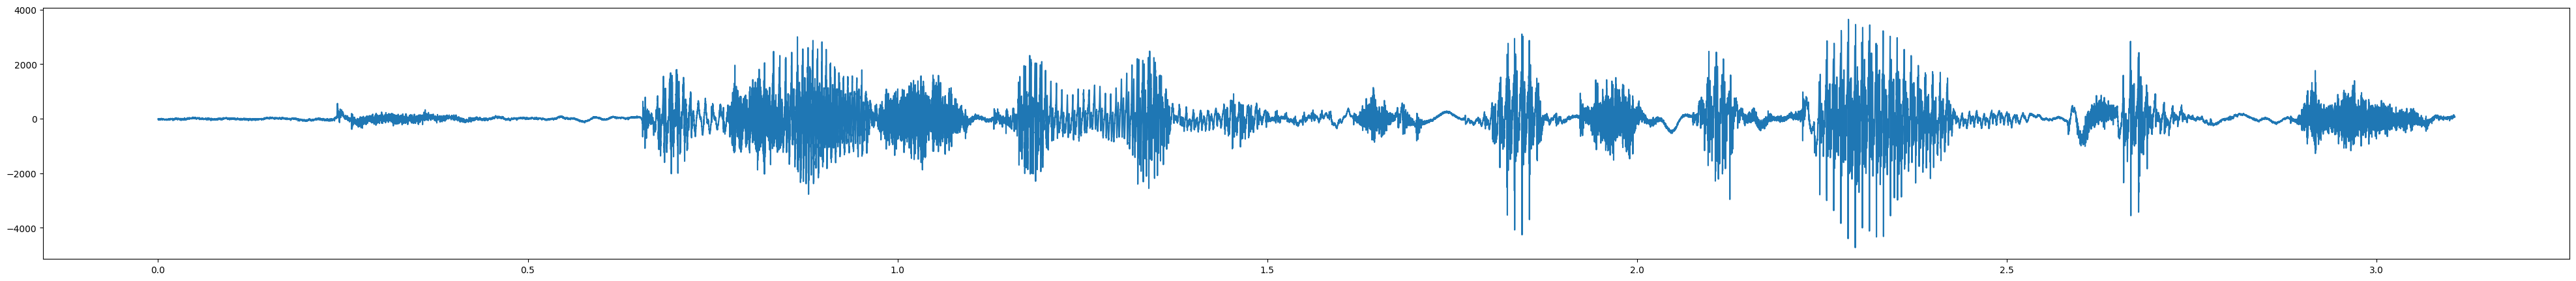

In [524]:
signal = np.frombuffer(frames, np.int16)

sec = np.linspace(0, len(signal)/rate, num = len(signal))
plt.figure(figsize=(50, 5))
plt.plot(sec, signal)
plt.show()

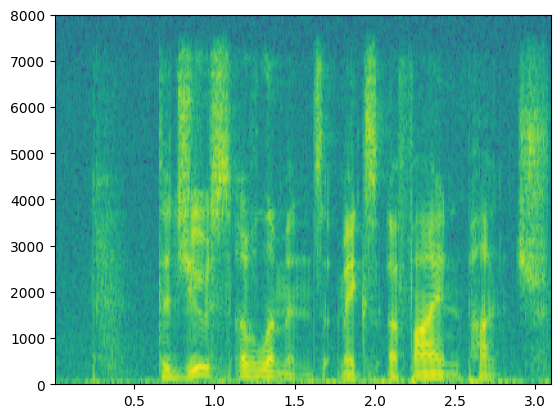

In [525]:
plt.specgram(signal,Fs=rate)
plt.show()

In [526]:
def log_square_magnitude(complex_num_array):
    mag = []
    for cn in complex_num_array:
        mag.append(10*np.log10((cn.real**2 + cn.imag**2)**.5))
    return mag

In [530]:
window_size_ms = 25
window_shift_ms = 10
frames_per_window =int( rate * window_size_ms / 1000)
frames_per_shift = int( rate * window_shift_ms / 1000)

pitch_detection = aubio.pitch("yin", frames_per_window, frames_per_shift,  rate)

windowed_fft = []
windowed_energy  = []
pitchs = []
confidence = []
i = 0
while i + frames_per_window < len(signal):
    window = signal[i: i+frames_per_window]
    window = window * np.hanning(frames_per_window)  
    windowed_energy.append(np.sum(window**2))
    fft = np.fft.fft(window)
    mags = log_square_magnitude(fft[:frames_per_window//2])
    windowed_fft.append(mags)
    i += int(frames_per_shift)
j=0
while j + frames_per_shift < len(signal):
      shift = signal[j: j+frames_per_shift]
      pitchs.append(pitch_detection(shift.astype(np.float32) / 32768.0)[0])
      confidence.append(pitch_detection.get_confidence())
      j += int(frames_per_shift)
spec = np.array(windowed_fft).T
energy = np.array(windowed_energy)
pitchs = np.array(pitchs[:len(sec)])
confidence = np.array(confidence[:len(sec)])
alpha = spec/spec.max()


In [531]:
freq, windows = alpha.shape

spectrogram = np.zeros((freq, windows, 4))

# Set color (blue)
spectrogram[...,1, 2,3] = 1.0

# Set alpha from magnitude
spectrogram[..., 3] = alpha

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.06874633140851852..1.0].


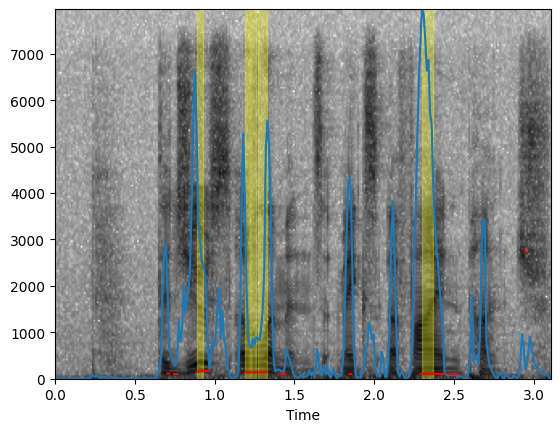

In [532]:
freqs = [i * rate / frames_per_window for i in range(len(spec))]
sec = np.linspace(0, len(signal)/rate, num = len(windowed_energy))
plt.imshow(spectrogram, 
           origin ='lower', 
           aspect ='auto',
           extent = [sec[0], sec[-1], freqs[0], freqs[-1]])
plt.xlabel("Time")
energy = energy/energy.max()
energy = energy * freqs[-1]
plt.plot(sec, energy)

pitchs_filtered[
    (confidence < .8) 
] = np.nan
plt.plot(sec, pitchs_filtered, color="red")

# Rising pitch detection
rise_regions = []
rise_threshold = 1
min_frames = 1    

def check_thresholds(start_index, end_index):
    return end_index - start_index >= min_frames and pitchs_filtered[end_index] - pitchs_filtered[start_index] >= rise_threshold

start = None
for i in range(1, len(pitchs_filtered)):
    if not np.isnan(pitchs_filtered[i-1]) and not np.isnan(pitchs_filtered[i]):
        if pitchs_filtered[i] > pitchs_filtered[i-1] and start is None:
            start = i-1
        elif pitchs_filtered[i] <= pitchs_filtered[i-1] and start is not None:
            if check_thresholds(start, i):
                rise_regions.append([start,i])
            start = None
    elif start is not None:
          if check_thresholds(start, i-1):
                rise_regions.append([start,i-1])
          start = None
if start is not None and check_thresholds(start, len(pitchs_filtered)-1):
    rise_regions.append([start, len(pitchs_filtered)-1])


for start, end in rise_regions:
    plt.axvspan(
        sec[start],
        sec[min(end, len(sec)-1)],
        color='yellow',
        alpha=0.3,
    )


plt.show()